<a href="https://colab.research.google.com/github/HARISHRAJ-R-07/Customer-Churn-Analysis/blob/main/Customer_Churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📊 Customer Churn Analysis

* **Business problem:**

A subscription company has 10,000 customers. Some customers cancel their subscriptions. Your goal is to identify the patterns associated with customers who churn.

####Imports Libraries: It imports essential Python libraries for data manipulation and visualization:
pandas (as pd): For working with dataframes.
numpy (as np): For numerical operations.
matplotlib.pyplot (as plt): For creating static, interactive, and animated visualizations.
seaborn (as sns): For statistical data visualization based on Matplotlib.
Loads Dataset: It reads a CSV file named customer_churn.csv into a pandas DataFrame and assigns it to the variable df.


In [22]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 2. Load dataset
df = pd.read_csv("customer_churn.csv")

In [23]:
df

,Customer_ID,Age,Gender,Plan,Monthly_Fee,Tenure,Usage_Hours,Support_Tickets,Payment_Method,Churn
0,CUST_00001,56,Male,Basic,699,17,42.4,1,UPI,0
1,CUST_00002,46,Female,Basic,599,26,14.4,5,UPI,1
2,CUST_00003,32,Female,Standard,299,41,71.8,3,Debit Card,0
3,CUST_00004,60,Female,Premium,599,4,66.9,2,Cash on Delivery,1
4,CUST_00005,25,Male,Premium,599,3,74.8,1,UPI,0
...,...,...,...,...,...,...,...,...,...,...
9995,CUST_09996,34,Male,Basic,799,57,45.6,3,Credit Card,0
9996,CUST_09997,47,Male,Premium,599,5,51.6,5,UPI,1
9997,CUST_09998,56,Male,Basic,599,39,19.3,5,Credit Card,1
9998,CUST_09999,24,Female,Premium,599,59,59.9,0,Credit Card,0


####Displaying First 5 Rows: display(df.head()) shows the first 5 rows of the df DataFrame. This gives a quick overview of the data's structure and content.
Dataset Information: df.info() prints a concise summary of the DataFrame, including the data types of each column, the number of non-null values, and memory usage. This is crucial for identifying data types that might need conversion and potential missing values.
Missing Values Count: df.isnull().sum() calculates the total number of missing (null) values for each column in the DataFrame. This helps in understanding the extent of missing data and deciding on appropriate imputation or handling strategies.

In [24]:
# 3. Understand the dataset
print("First 5 rows:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

First 5 rows:


,Customer_ID,Age,Gender,Plan,Monthly_Fee,Tenure,Usage_Hours,Support_Tickets,Payment_Method,Churn
0,CUST_00001,56,Male,Basic,699,17,42.4,1,UPI,0
1,CUST_00002,46,Female,Basic,599,26,14.4,5,UPI,1
2,CUST_00003,32,Female,Standard,299,41,71.8,3,Debit Card,0
3,CUST_00004,60,Female,Premium,599,4,66.9,2,Cash on Delivery,1
4,CUST_00005,25,Male,Premium,599,3,74.8,1,UPI,0



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer_ID      10000 non-null  object 
 1   Age              10000 non-null  int64  
 2   Gender           10000 non-null  object 
 3   Plan             10000 non-null  object 
 4   Monthly_Fee      10000 non-null  int64  
 5   Tenure           10000 non-null  int64  
 6   Usage_Hours      10000 non-null  float64
 7   Support_Tickets  10000 non-null  int64  
 8   Payment_Method   10000 non-null  object 
 9   Churn            10000 non-null  int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 781.4+ KB

Missing Values:
Customer_ID        0
Age                0
Gender             0
Plan               0
Monthly_Fee        0
Tenure             0
Usage_Hours        0
Support_Tickets    0
Payment_Method     0
Churn              0
dtype: int64


In [25]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
9995,False
9996,False
9997,False
9998,False


***Load → Understand → Clean → Analyze Churn → Find Patterns → Visualize → Give Business Insights***

In [26]:
# 4. Data cleaning
df.drop_duplicates(inplace=True)

# Check churn distribution
print("\nChurn Distribution:")
print(df["Churn"].value_counts())


# 5. Overall churn rate
churn_rate = df["Churn"].mean() * 100

print(f"\nOverall Churn Rate: {churn_rate:.2f}%")


Churn Distribution:
Churn
1    5986
0    4014
Name: count, dtype: int64

Overall Churn Rate: 59.86%


In [27]:
# 6. Churn by Plan
churn_by_plan = (
    df.groupby("Plan")["Churn"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

print("\nChurn Rate by Plan:")
print(churn_by_plan)


# 7. Churn by Gender
churn_by_gender = (
    df.groupby("Gender")["Churn"]
      .mean()
      .mul(100)
)

print("\nChurn Rate by Gender:")
print(churn_by_gender)



Churn Rate by Plan:
Plan
Premium     60.545809
Basic       59.669948
Standard    59.583019
Name: Churn, dtype: float64

Churn Rate by Gender:
Gender
Female    59.816074
Male      59.903962
Name: Churn, dtype: float64


In [28]:
# 8. Churn by Payment Method
churn_by_payment = (
    df.groupby("Payment_Method")["Churn"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

print("\nChurn Rate by Payment Method:")
print(churn_by_payment)


# 9. Compare numerical features
print("\nAverage Values by Churn:")
display(
    df.groupby("Churn")[
        ["Age", "Monthly_Fee", "Tenure",
         "Usage_Hours", "Support_Tickets"]
    ].mean()
)


Churn Rate by Payment Method:
Payment_Method
Debit Card          61.066127
Cash on Delivery    60.282258
UPI                 60.011233
Net Banking         59.986859
Credit Card         58.657388
Name: Churn, dtype: float64

Average Values by Churn:


,Age,Monthly_Fee,Tenure,Usage_Hours,Support_Tickets
Churn,,,,,
0,41.513951,542.946188,36.137519,45.552790,2.809168
1,41.586869,556.684597,27.112429,37.729552,3.139325


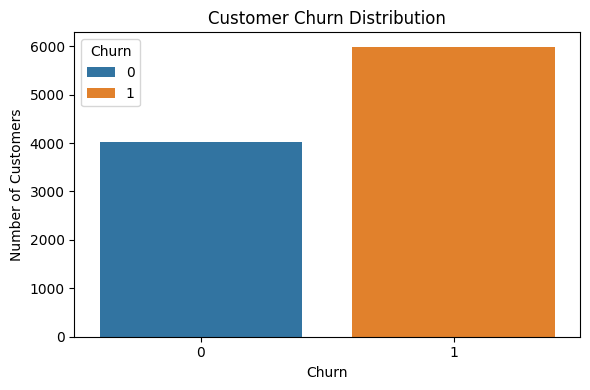

In [29]:
# 10. Visualization - Churn Distribution
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Churn",
    hue="Churn",
    legend=True
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


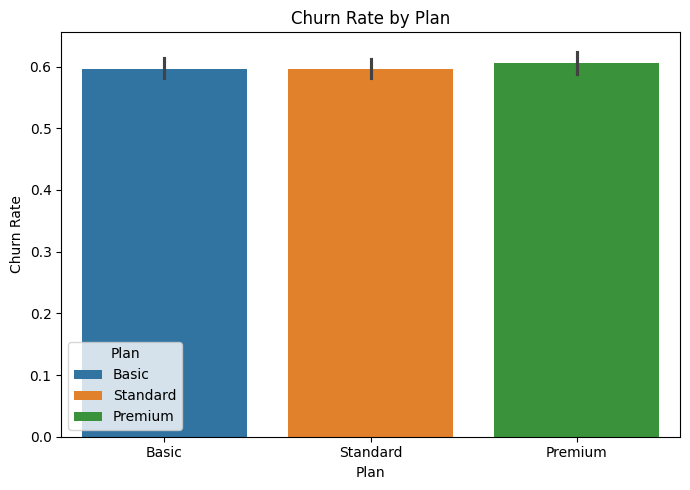

In [30]:
# 11. Visualization - Churn by Plan
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="Plan",
    y="Churn",
    hue="Plan",
    legend=True
)

plt.title("Churn Rate by Plan")
plt.xlabel("Plan")
plt.ylabel("Churn Rate")
plt.tight_layout()
plt.show()


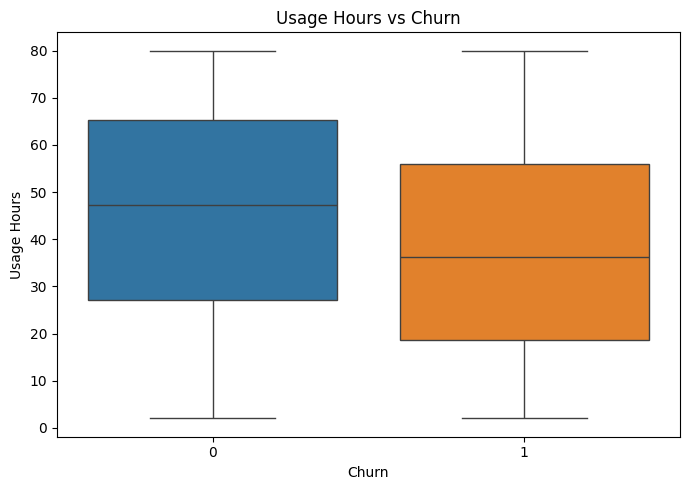

In [31]:
# 12. Visualization - Usage vs Churn
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="Usage_Hours",
    hue="Churn",
    legend=False
)

plt.title("Usage Hours vs Churn")
plt.xlabel("Churn")
plt.ylabel("Usage Hours")
plt.tight_layout()
plt.show()

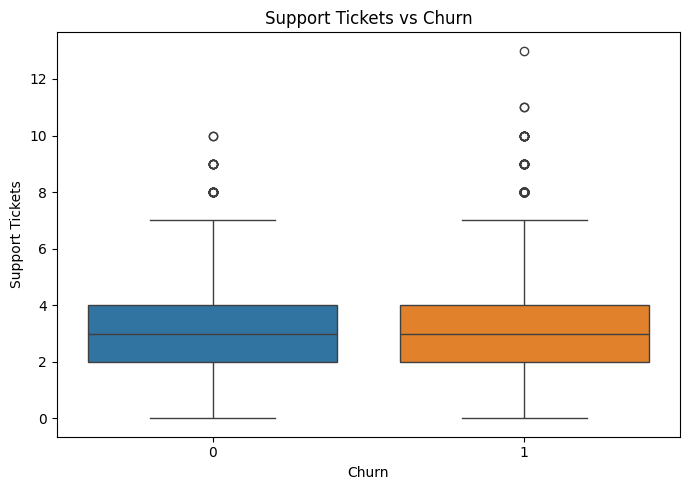

In [32]:
# 13. Visualization - Support Tickets vs Churn
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="Support_Tickets",
    hue="Churn",
    legend=False
)

plt.title("Support Tickets vs Churn")
plt.xlabel("Churn")
plt.ylabel("Support Tickets")
plt.tight_layout()
plt.show()

In [33]:
df[['Churn','Support_Tickets']]

,Churn,Support_Tickets
0,0,1
1,1,5
2,0,3
3,1,2
4,0,1
...,...,...
9995,0,3
9996,1,5
9997,1,5
9998,0,0


### Conclusion: Support Tickets vs Churn

The analysis shows that customers with a higher number of **support tickets** are more likely to churn. This indicates that frequent support problems may be associated with customer dissatisfaction and can increase the likelihood of customers leaving the service.

**Key Insight:** Customers facing more support issues should be identified early and provided with faster and better support to improve customer retention.
